In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from abstract_values.utils.data import BIDS_FOLDER

In [2]:
# ── settings ──────────────────────────────────────────────────────────────────
mask    = 'NPCr'
n_voxels = 100

subjects_sessions = [
    ('pil01', 1),
    ('pil01', 2),
    ('pil02', 1),
]

deriv_dir = BIDS_FOLDER / 'derivatives' / 'encoding_models' / 'aprf'

In [3]:
def load_fisher_info(subject, session, mask, n_voxels):
    fn = (deriv_dir / f'sub-{subject}' / f'ses-{session}' / 'func' /
          f'sub-{subject}_ses-{session}_task-abstractvalue'
          f'_mask-{mask}_nvoxels-{n_voxels}_desc-fisherinfo_pe.tsv')
    df = pd.read_csv(fn, sep='\t', index_col=0)
    df.index.name = 'value_chf'
    return df['fisher_information']


fi = {}
for subject, session in subjects_sessions:
    key = f'sub-{subject}  ses-{session}'
    fi[key] = load_fisher_info(subject, session, mask, n_voxels)
    peak_val = fi[key].idxmax()
    print(f'{key}: mean FI={fi[key].mean():.3f}  peak at {peak_val:.2f} CHF')

sub-pil01  ses-1: mean FI=3.073  peak at 21.12 CHF
sub-pil01  ses-2: mean FI=37.038  peak at 29.55 CHF
sub-pil02  ses-1: mean FI=107.065  peak at 22.41 CHF


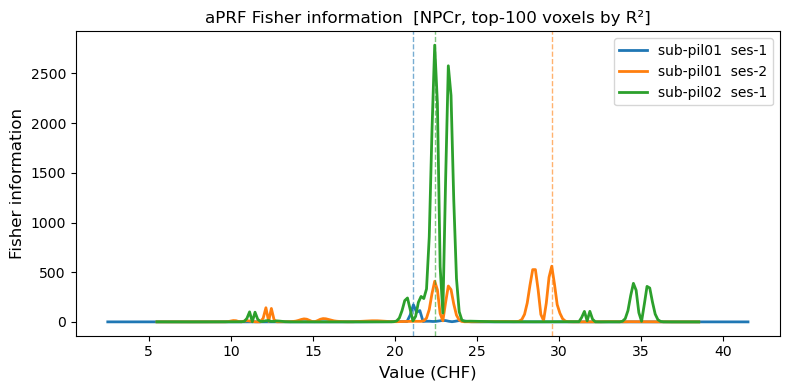

In [4]:
# ── plot all curves on one axis ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

colors = plt.cm.tab10.colors
for i, (label, series) in enumerate(fi.items()):
    ax.plot(series.index, series.values, lw=2, color=colors[i], label=label)
    ax.axvline(series.idxmax(), color=colors[i], lw=1, linestyle='--', alpha=0.6)

ax.set_xlabel('Value (CHF)', fontsize=12)
ax.set_ylabel('Fisher information', fontsize=12)
ax.set_title(f'aPRF Fisher information  [{mask}, top-{n_voxels} voxels by R²]', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

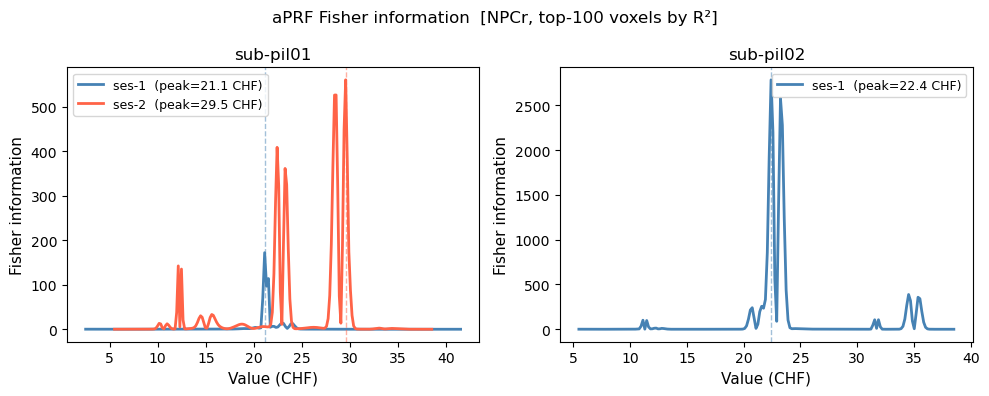

In [5]:
# ── separate panels per subject ────────────────────────────────────────────────
subjects = sorted({s for s, _ in subjects_sessions})
fig, axes = plt.subplots(1, len(subjects), figsize=(5 * len(subjects), 4), sharey=False)

if len(subjects) == 1:
    axes = [axes]

ses_colors = {'1': 'steelblue', '2': 'tomato', '3': 'seagreen'}

for ax, subject in zip(axes, subjects):
    for label, series in fi.items():
        if f'sub-{subject}' not in label:
            continue
        ses_num = label.split('ses-')[1].strip()
        color = ses_colors.get(ses_num, 'gray')
        ax.plot(series.index, series.values, lw=2, color=color,
                label=f'ses-{ses_num}  (peak={series.idxmax():.1f} CHF)')
        ax.axvline(series.idxmax(), color=color, lw=1, linestyle='--', alpha=0.5)

    ax.set_xlabel('Value (CHF)', fontsize=11)
    ax.set_ylabel('Fisher information', fontsize=11)
    ax.set_title(f'sub-{subject}', fontsize=12)
    ax.legend(fontsize=9)

fig.suptitle(f'aPRF Fisher information  [{mask}, top-{n_voxels} voxels by R²]', fontsize=12)
plt.tight_layout()
plt.show()